# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Juliette Whelan
* Username: jrwhelan
* Student number: s6211860
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

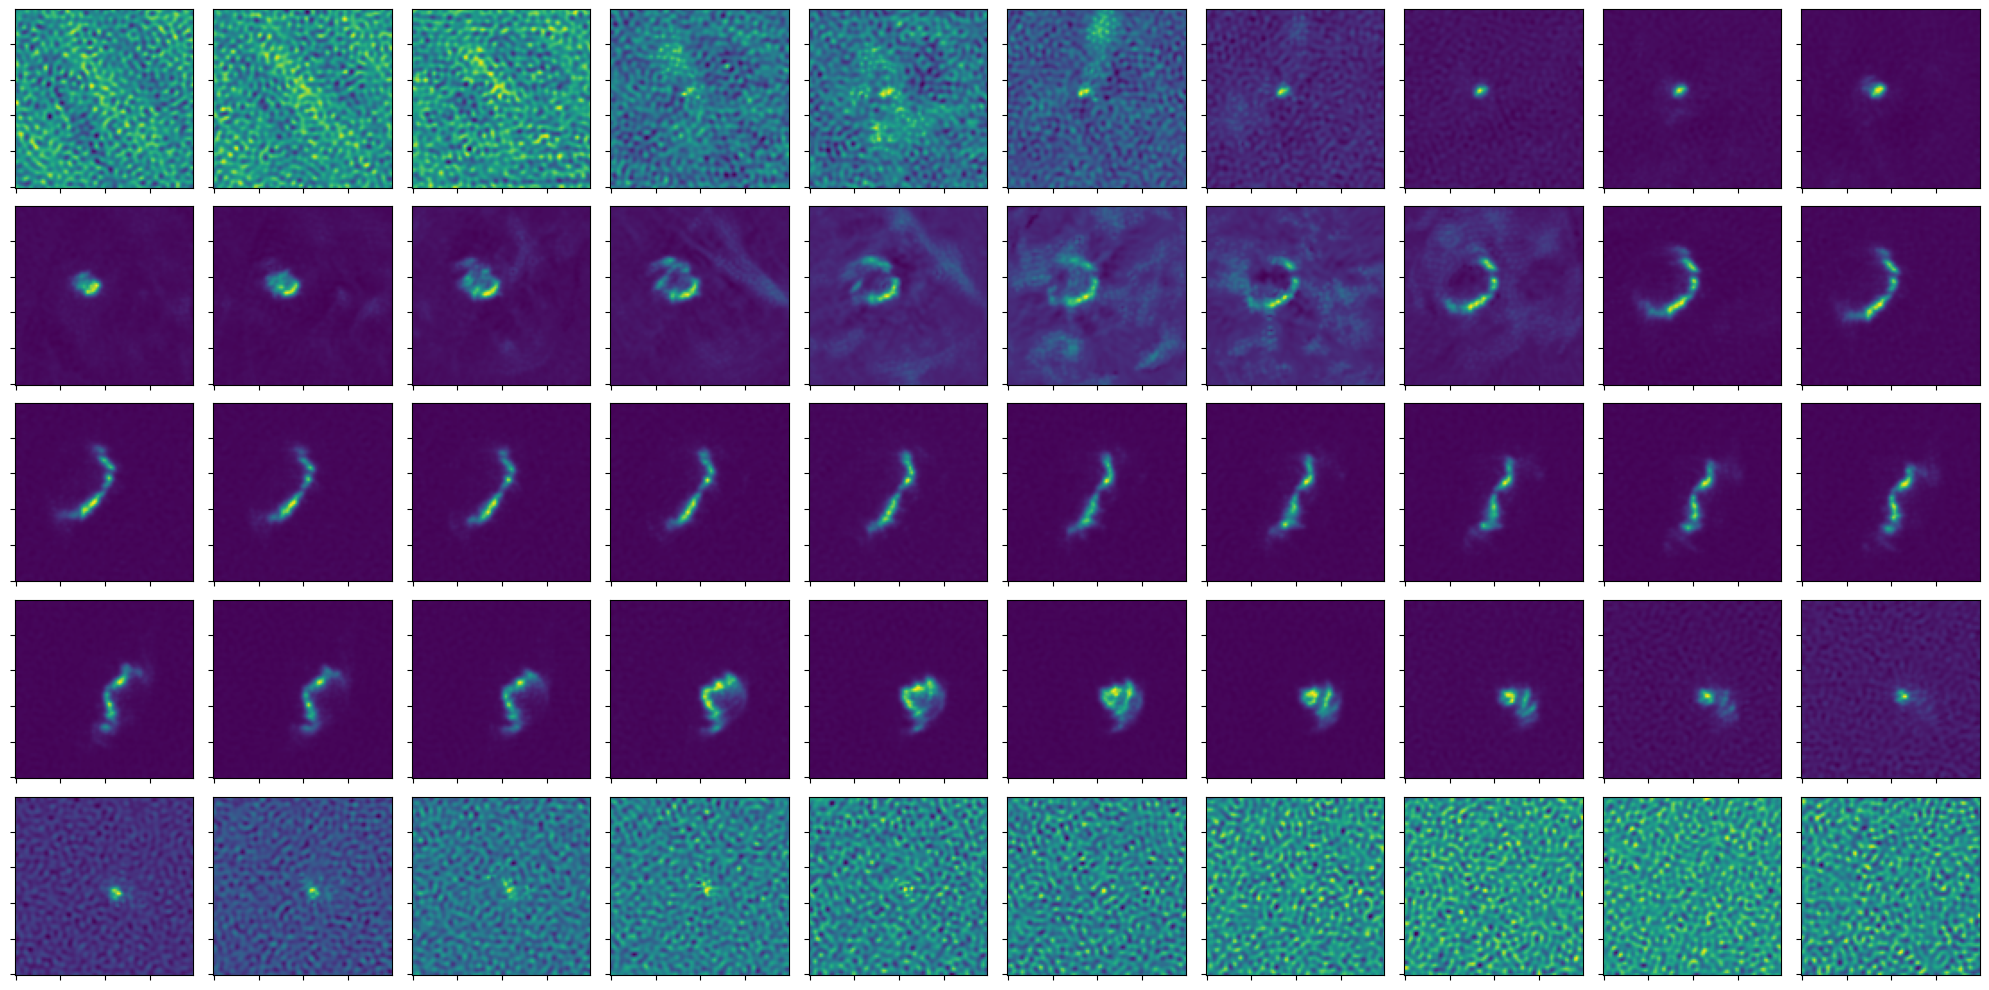

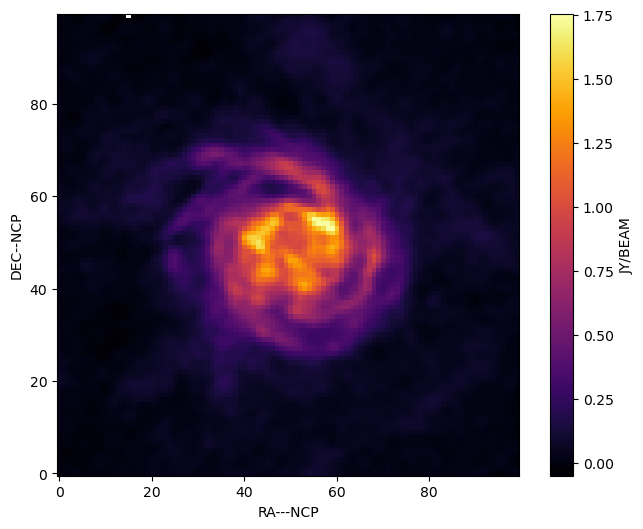

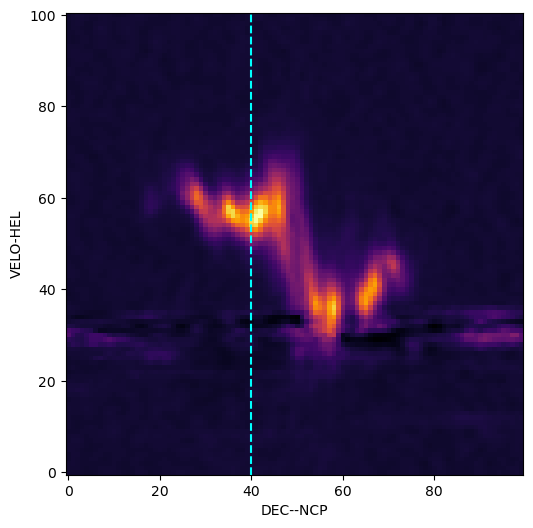

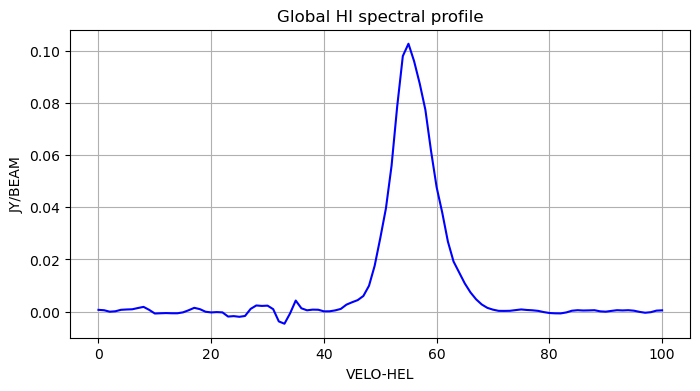

In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Download/Load data

hdul = fits.open('ngc6946.fits')
data = hdul[0].data   # (Z, Y, X)
header = hdul[0].header
hdul.close()

# Create mosaic

channels = range(1, 101, 2)
nrows, ncols = 5, 10
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))

# Making the plots

for i, c in enumerate(channels):
    # Determine the row and column for this subplot
    row = i // ncols    # Integer division to get the row index
    col = i % ncols     # Modulus to get the column index
    frame = axes[row, col]
    image = frame.imshow(data[c], origin='lower', cmap='viridis')
    frame.set_xticklabels([])
    frame.set_yticklabels([])

plt.tight_layout()
plt.show()

# Making the total HI plot

total_HI = np.sum(data[14:80], axis=0)

fig2, frame2 = plt.subplots(figsize=(8, 6))
im = frame2.imshow(total_HI, origin='lower', cmap='inferno')

# Label axes
frame2.set_xlabel(header['CTYPE1'])
frame2.set_ylabel(header['CTYPE2'])

# Add a normal colorbar
cbar = plt.colorbar(im)  
cbar.set_label(header['BUNIT'])

plt.show()

# PV Map

RA_index = 50
DE_index = 40

PV_map = data[:,:,RA_index]

fig3, frame3 = plt.subplots(figsize=(8, 6))
im = frame3.imshow(PV_map, origin='lower', cmap='inferno')

# Plot a vertical line at Dec. with index 40
frame3.axvline(DE_index, color='cyan', linestyle='--')
frame3.set_xlabel(header['CTYPE2'])
frame3.set_ylabel(header['CTYPE3'])
plt.show()

# Global HI spectral profile

global_profile = data[:, DE_index, RA_index]  # along spectral axis

plt.figure(figsize=(8, 4))
plt.plot(global_profile, color='blue')
plt.xlabel(header['CTYPE3'])
plt.ylabel(header['BUNIT'])
plt.title('Global HI spectral profile')
plt.grid(True)
plt.show()

# The vertical line in de PV map is the position at which the global HI is measured. 

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

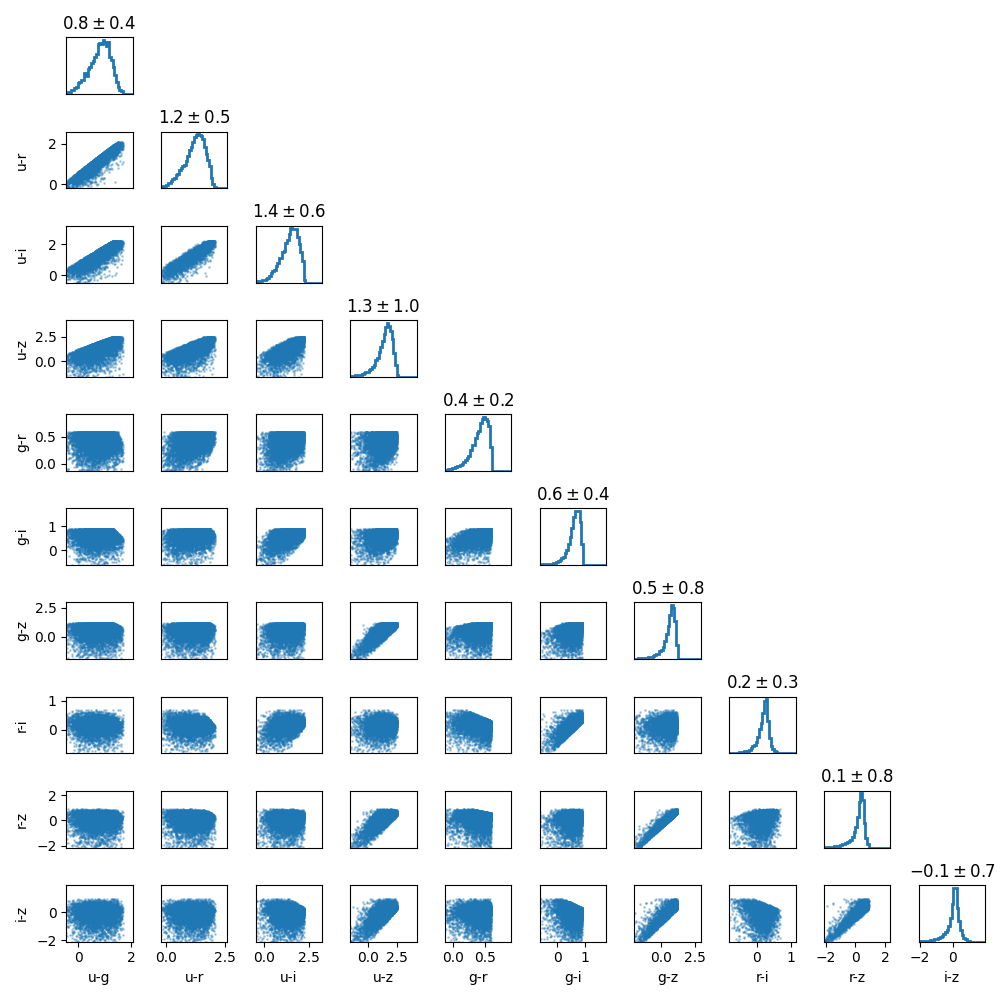
   
**Plot and answer**:

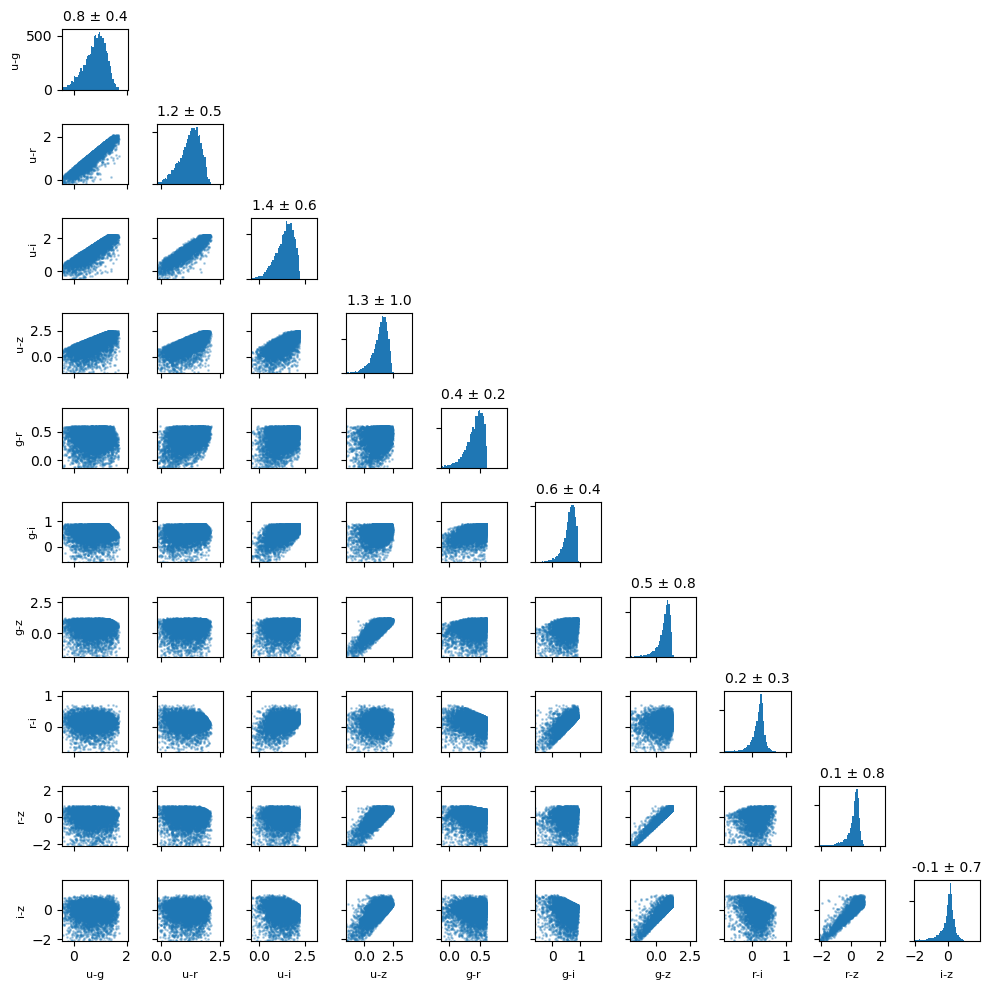

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Load FITS file

hdul = fits.open('SDSS_DR17_galaxies.fits')
data = hdul[1].data  # assuming table is in extension 1
hdul.close()

# 2. Convert to Pandas DataFrame

df = pd.DataFrame(np.array(data).byteswap().view(np.array(data).dtype.newbyteorder('='))) # Convert input data into a NumPy array, correct the byte order

# Select only SDSS bands

bands = ['u', 'g', 'r', 'i', 'z']
df = df[bands]

# 3. Filter out negative values (rows)

df = df[(df > 0).all(axis=1)].copy()

# 4. Calculate all colour combinations

colour_names = []

for i in range(len(bands)):
    for j in range(i + 1, len(bands)):
        b1 = bands[i]
        b2 = bands[j]
        
        col_name = f"{b1}-{b2}"
        df[col_name] = df[b1] - df[b2]  # Adding the combination to de df with columnname and values
        
        colour_names.append(col_name)   # Adding it to the list above

# Keep only colour columns

colour_df = df[colour_names]

# 5. Calculate mean and std

stats = {}
for col in colour_names:
    mean = colour_df[col].mean()
    std = colour_df[col].std()
    stats[col] = (mean, std)

# 6. Corner plot 

n = len(colour_names)
fig, axes = plt.subplots(n, n, figsize=(10, 10))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

# Make it a corner plot:
        if j > i:
            ax.axis('off') 
            continue

        if i == j:
            # Histogram
            mean, std = stats[colour_names[i]]
            xmin, xmax = mean - 3*std, mean + 3*std

            ax.hist(colour_df[colour_names[i]], bins=50, range=(xmin, xmax))
            ax.set_xlim(xmin, xmax)

            ax.set_title(f"{mean:.1f} ± {std:.1f}", fontsize=10)    # Gives the titel

        else:
            xcol = colour_names[j]
            ycol = colour_names[i]

            mean_x, std_x = stats[xcol]
            mean_y, std_y = stats[ycol]

            ax.scatter(colour_df[xcol], colour_df[ycol], s=1, alpha=0.3)

            ax.set_xlim(mean_x - 3*std_x, mean_x + 3*std_x)
            ax.set_ylim(mean_y - 3*std_y, mean_y + 3*std_y)

        # no ticks
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

# Axis labels

for i, col in enumerate(colour_names):
    axes[-1, i].set_xlabel(col, fontsize=8)
    axes[i, 0].set_ylabel(col, fontsize=8)

plt.tight_layout()
plt.show()


In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

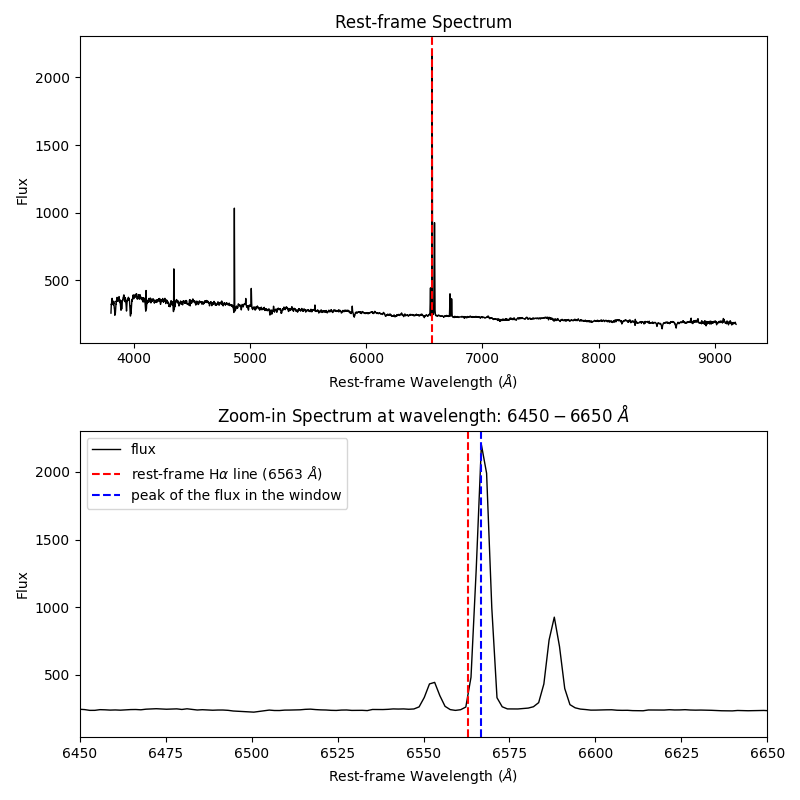

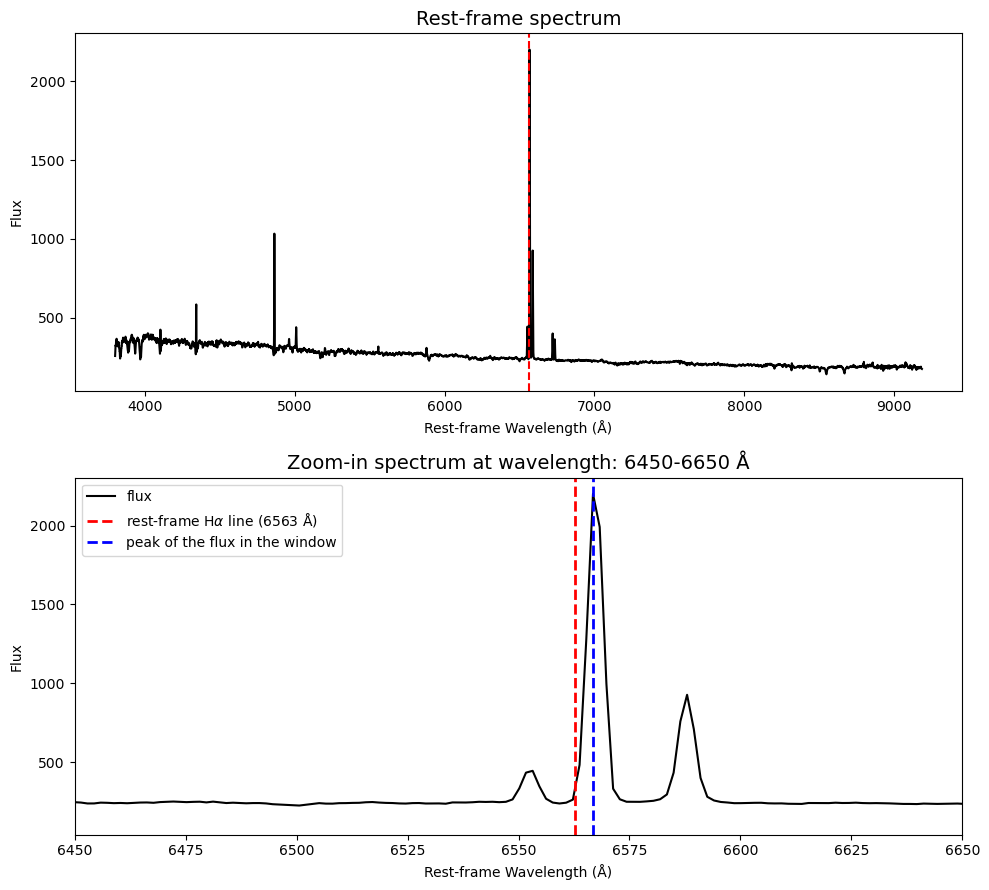

Velocity = 182.05 km/s


In [6]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)

sp = SDSS.get_spectra(matches=xid)

hdul = sp[0]

dat = hdul[1].data
flux = dat["flux"]
wavelength_log = dat["loglam"]
wavelength_obs = 10**wavelength_log
z = 0.0038
rest_wavelength = wavelength_obs/(1+z)

halpha_rest = 6562.8

zoom_min = 6450
zoom_max = 6650

peakflux = flux.max()

zoom_mask = (rest_wavelength >= zoom_min) & (rest_wavelength <= zoom_max)

wave_zoom = rest_wavelength[zoom_mask]
flux_zoom = flux[zoom_mask]

# Index of max flux

idx = np.argmax(flux[zoom_mask])

# Wavelength with it

peak_wave_rest = rest_wavelength[zoom_mask][idx]
peak_flux = flux[zoom_mask][idx]

# Object-oriented plotting

fig, (frame1, frame2) = plt.subplots(2, 1, figsize=(10, 9), sharex=False)

# Top plot

frame1.plot(rest_wavelength, flux, lw=1.5, color='black', label="Rest-frame spectrum")
frame1.axvline(halpha_rest, ls="--", lw=1.5, color='red', label=r"rest-frame H$\alpha$ line (6563 Å)")

frame1.set_title("Rest-frame spectrum", fontsize=14)
frame1.set_xlabel("Rest-frame Wavelength (Å)", fontsize=10)
frame1.set_ylabel("Flux", fontsize=10)

# Bottom plot

frame2.plot(rest_wavelength, flux, lw=1.5 ,color='black', label="flux")
frame2.set_xlim(6450, 6650)

# Expected observed H-alpha from z

halpha_obs_expected = halpha_rest * (1 + z)

frame2.axvline(halpha_rest, ls="--", lw=2, color='red', label=r"rest-frame H$\alpha$ line (6563 Å)")
frame2.axvline(peak_wave_rest, ls="--", lw=2, color='blue', label="peak of the flux in the window")

frame2.set_title("Zoom-in spectrum at wavelength: 6450-6650 Å", fontsize=14)
frame2.set_xlabel("Rest-frame Wavelength (Å)", fontsize=10)
frame2.set_ylabel("Flux", fontsize=10)
frame2.legend(loc='upper left', fontsize=10)

frame1.tick_params(axis='both', labelsize=10)  
frame2.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

# Calculating velocity

delta_lambda = peak_wave_rest - halpha_rest
c_kms = 299792.458  # km/s

velocity_kms = c_kms * (delta_lambda / halpha_rest)

print(f"Velocity = {velocity_kms:.2f} km/s")

# See markdown for last question

The offset could be caused by the own motion of the galaxy. The redshift is not only from the expansion of the universe but is also caused by other velocity components, like rotation and its motion inside a cluster for example.

The offset could be caused by the own motion of the galaxy. The redshift is not only from the expansion of the universe but is also caused by other velocity components.

In [7]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

hdul = fits.open("20210422_Li_.00000066.FIT")
fits_data = hdul[0].data
hdul.close()

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    """
    Display an image on the input axes with different scaling options.
    
    Parameters:
    - data: 2D numpy array (image data)
    - ax: Matplotlib axis object to plot the image on
    - vmin, vmax: Min and max values for image scaling
    - percentlow, percenthigh: Percentile for image scaling
    - zscale: Boolean to use ZScale normalization
    - scale: Type of scaling to apply 
    - power: Exponent for 'power' scaling
    - cmap: Color map for the image display
    """
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

# Create the figure with subplots
fig, ax = plt.subplots(2, 4, figsize=(16, 8))  # 2 rows, 4 columns
axs = ax.flatten()  # Flatten the axes array

# List of all scaling types
scales = ['none', 'linear', 'log', 'sinh', 'power', 'sqrt', 'squared', 'hist']

# Display the images with different scaling
for i, scale in enumerate(scales):
    if scale == 'none':
        # Plot the original image without any scaling
        imdisplay(fits_data, axs[i], cmap='gray')
        axs[i].set_title('Original Image', fontsize=14)
    else:
        imdisplay(fits_data, axs[i], scale=scale, cmap='gray')
        axs[i].set_title(f'{scale.capitalize()} Scale', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()

/opt/anaconda-hub/lib/python3.13/site-packages/astropy/visualization/stretch.py:543: RuntimeWarning: overflow encountered in sinh
  np.sinh(values, out=values)
/opt/anaconda-hub/lib/python3.13/site-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [ ]:
from pathlib import Path
from matplotlib.pyplot import subplots, show
import numpy as np
from astropy.io import fits
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
import astroalign as aa

datadir = "/Users/users/jrwhelan/DATASERVER"  # Replace by your own data folder (not in home!)
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts', '.FIT']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)


from matplotlib.pyplot import figure, show
from math import ceil

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()    

excludes = ['20210418_Li_.00000032.FIT', '20210418_Li_.00000033.FIT']
new_filepaths = []
for filepath in filepaths:
    if not filepath.name in excludes:
        new_filepaths.append(filepath)

# Read the images

images = []
for filepath in new_filepaths:
    hdulist = fits.open(filepath)
    images.append(hdulist[0].data.astype('float'))
    hdulist.close()

# Stacking

datacube = np.stack(images)
stacked_images = np.median(datacube, axis=0)


# Showing the plot after stacking

fig, ax = subplots()
imdisplay(stacked_images, ax, percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
show()

# Aligning

target = new_filepaths[6]
newim = new_filepaths[4]

hdulist = fits.open(target)
target_im = hdulist[0].data.astype('float')
hdulist = fits.open(newim)
tobealigned_im = hdulist[0].data.astype('float')

aligned_im, footprint = aa.register(tobealigned_im, target_im, detection_sigma=3.0)

fig, ax = subplots(3)
fig.set_size_inches(8,6)
imdisplay(target_im, ax[0], percentlow=5, percenthigh=95, scale='squared')
ax[0].set_title('target')
imdisplay(tobealigned_im, ax[1], percentlow=5, percenthigh=95, scale='squared')
ax[1].set_title('align candidate')
imdisplay(aligned_im, ax[2], percentlow=5, percenthigh=95, scale='squared')
ax[2].set_title('align result')
fig.tight_layout()
show()

hdulist = fits.open(target)
target_im = hdulist[0].data.astype('float')

images2 = []
for filepath in new_filepaths:
    if not filepath.name in excludes:
        print(f"Aligning: {filepath}")
        hdulist = fits.open(filepath)
        tobealigned_im = hdulist[0].data.astype('float')
        try:
            aligned_im, footprint = aa.register(tobealigned_im,
                                                target_im,
                                                detection_sigma=5.0,
                                                max_control_points=100,
                                                min_area=5)
            images2.append(aligned_im)
        except:
            print("Failed")
        hdulist.close()

datacube2 = np.stack(images2)

stacked_reg_images = np.median(datacube2, axis=0)

fig, ax = subplots()
imdisplay(np.flipud(stacked_reg_images), ax, percentlow=5, percenthigh=95,
          scale='squared', cmap='twilight')
show() 

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")